<a href="https://colab.research.google.com/github/johncase17/Data-Science-Project-1/blob/main/KPConvSeeded.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# KPConv — SemanticKITTI Training Notebook

> **Run cells top-to-bottom.** Each section must complete before the next.

---

## 1. Verify GPU

In [ ]:
!nvidia-smi

Wed Jul  8 20:50:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import torch
print('CUDA available:', torch.cuda.is_available())
print('GPU name:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'No GPU')
print('CUDA version:', torch.version.cuda)

CUDA available: True
GPU name: Tesla T4
CUDA version: 12.8


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

NOTEBOOK_DIR = "/content/drive/MyDrive/Colab Notebooks/TerrainClassificationDL"
print(f"Notebook dir: {NOTEBOOK_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Notebook dir: /content/drive/MyDrive/Colab Notebooks/TerrainClassificationDL


In [ ]:
import zipfile, time, os

ZIP_PATH = os.path.join(NOTEBOOK_DIR, 'semkitti_research.zip')
DATA_DIR = '/content/KPConv-PyTorch/Data/SemanticKitti'
SEQ_DST  = os.path.join(DATA_DIR, 'sequences')
os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(SEQ_DST):
    print('Extracting sequences from zip...')
    t0 = time.time()
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        members = [m for m in z.namelist()
                   if 'semantickitti_subsampled/sequences/' in m]
        for member in members:
            rel = member.split('semantickitti_subsampled/sequences/')[-1]
            if not rel: continue
            dst = os.path.join(SEQ_DST, rel)
            if member.endswith('/'):
                os.makedirs(dst, exist_ok=True)
            else:
                os.makedirs(os.path.dirname(dst), exist_ok=True)
                with z.open(member) as src, open(dst, 'wb') as out:
                    out.write(src.read())
    print(f'Done in {time.time()-t0:.0f}s')
else:
    print('Already extracted, skipping.')

YAML_DST = os.path.join(DATA_DIR, 'semantic-kitti.yaml')
if not os.path.exists(YAML_DST):
    import urllib.request
    print('Downloading semantic-kitti.yaml...')
    urllib.request.urlretrieve(
        'https://raw.githubusercontent.com/PRBonn/semantic-kitti-api/master/config/semantic-kitti.yaml',
        YAML_DST)
    print('Done')

print(f'Sequences: {sorted(os.listdir(SEQ_DST))}')

Already extracted, skipping.
Sequences: ['00', '01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21']


---

## 2. Install condacolab

> ⚠️ The runtime will **restart automatically** after this cell. That is expected — just continue from the next cell after restart.

In [ ]:
!pip install -q condacolab
import condacolab
condacolab.install()  # Runtime restarts here — continue from Step 3 after restart

✨🍰✨ Everything looks OK!


---

## 3. Create conda environment (Python 3.8)

> Run this after the runtime has restarted from Step 2.

In [ ]:
%%bash
cd /
conda clean --all -y
conda create -y -n kpconv python=3.8
conda env list

Will remove 84 (59.1 MB) tarball(s).
Will remove 1 index cache(s).
Will remove 6 (593 KB) package(s).
There are no tempfile(s) to remove.
There are no logfile(s) to remove.
Channels:
 - conda-forge
Platform: linux-64
Solving environment: ...working... done

## Package Plan ##

  environment location: /usr/local/envs/kpconv

  added / updated specs:
    - python=3.8


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    _openmp_mutex-4.5          |           20_gnu          28 KB  conda-forge
    bzip2-1.0.8                |       hda65f42_9         254 KB  conda-forge
    ca-certificates-2026.6.17  |       hbd8a1cb_0         126 KB  conda-forge
    ld_impl_linux-64-2.45.1    |default_hbd61a6d_102         711 KB  conda-forge
    libffi-3.7.0               |       h3435931_0          66 KB  conda-forge
    libgcc-15.2.0              |      he0feb66_19        1017 KB  conda-forge
    libgcc-ng-1



==> WARNING: A newer version of conda exists. <==
    current version: 24.11.2
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c conda-forge conda




In [ ]:
%%bash
/usr/local/envs/kpconv/bin/python --version

Python 3.8.20


---

## 4. Install dependencies into kpconv env

> We install PyTorch 1.10 (required by KPConv-PyTorch) **only** inside the kpconv env.
> We do NOT touch the base Colab environment.

In [ ]:
%%bash
# Core scientific packages
/usr/local/envs/kpconv/bin/pip install --quiet \
    numpy==1.21.6 scipy scikit-learn matplotlib pyyaml

# setuptools pin needed for KPConv C++ build
/usr/local/envs/kpconv/bin/pip install --quiet setuptools==59.5.0

# PyTorch 1.10 + CUDA 11.3 (compatible with KPConv-PyTorch)
/usr/local/envs/kpconv/bin/pip install --quiet \
    torch==1.10.0+cu113 torchvision==0.11.1+cu113 \
    --extra-index-url https://download.pytorch.org/whl/cu113

echo 'All dependencies installed.'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.7/15.7 MB 100.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 146.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 132.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 146.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 806.0/806.0 kB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 138.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 75.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 90.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.4/952.4 kB 24.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 GB 28.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 168.6 MB/s eta 0:00:00
All dependencies installed.


---

## 5. Clone KPConv-PyTorch repository

In [ ]:
%%bash
rm -rf /content/KPConv-PyTorch
git clone https://github.com/HuguesTHOMAS/KPConv-PyTorch.git /content/KPConv-PyTorch
echo 'Repo contents:'
ls /content/KPConv-PyTorch

Repo contents:
cpp_wrappers
datasets
doc
INSTALL.md
kernels
LICENSE.txt
models
plot_convergence.py
README.md
test_models.py
train_ModelNet40.py
train_NPM3D.py
train_S3DIS.py
train_SemanticKitti.py
train_SensatUrban.py
train_Toronto3D.py
utils
visualize_deformations.py


Cloning into '/content/KPConv-PyTorch'...


---

## 6. Compile C++ wrappers

> This is required for KPConv's radius search and subsampling operations.
> Watch for `SUCCESS` at the end — if it says `FAILED`, check the CUDA version mismatch.

In [ ]:
%%bash
cd /content/KPConv-PyTorch/cpp_wrappers
export PATH=/usr/local/envs/kpconv/bin:$PATH

echo '--- Python being used ---'
which python && python --version

echo '--- Compiling wrappers ---'
bash compile_wrappers.sh && echo 'SUCCESS: C++ wrappers compiled.' || echo 'FAILED: Check CUDA/compiler version.'

--- Python being used ---
/usr/local/envs/kpconv/bin/python
Python 3.8.20
--- Compiling wrappers ---
running build_ext
building 'grid_subsampling' extension
Make sure that Python modules winreg, win32api or win32con are installed.
C compiler: gcc -pthread -B /usr/local/envs/kpconv/compiler_compat -Wno-unused-result -Wsign-compare -DNDEBUG -fwrapv -O2 -Wall -fPIC -O2 -isystem /usr/local/envs/kpconv/include -fPIC -O2 -isystem /usr/local/envs/kpconv/include -fPIC

creating build
creating build/temp.linux-x86_64-3.8
creating build/temp.linux-x86_64-3.8/cpp_wrappers
creating build/temp.linux-x86_64-3.8/cpp_wrappers/cpp_utils
creating build/temp.linux-x86_64-3.8/cpp_wrappers/cpp_utils/cloud
creating build/temp.linux-x86_64-3.8/grid_subsampling
compile options: '-I/usr/local/envs/kpconv/lib/python3.8/site-packages/numpy/core/include -I/usr/local/envs/kpconv/include/python3.8 -c'
extra options: '-std=c++11 -D_GLIBCXX_USE_CXX11_ABI=0'
gcc: ../cpp_utils/cloud/cloud.cpp
gcc: grid_subsampling/grid

In file included from /usr/local/envs/kpconv/lib/python3.8/site-packages/numpy/core/include/numpy/ndarraytypes.h:1969,
                 from /usr/local/envs/kpconv/lib/python3.8/site-packages/numpy/core/include/numpy/ndarrayobject.h:12,
                 from /usr/local/envs/kpconv/lib/python3.8/site-packages/numpy/core/include/numpy/arrayobject.h:4,
                 from wrapper.cpp:2:
/usr/local/envs/kpconv/lib/python3.8/site-packages/numpy/core/include/numpy/npy_1_7_deprecated_api.h:17:2: warning: #warning "Using deprecated NumPy API, disable it with " "#define NPY_NO_DEPRECATED_API NPY_1_7_API_VERSION" [-Wcpp]
   17 | #warning "Using deprecated NumPy API, disable it with " \
      |  ^~~~~~~
grid_subsampling/grid_subsampling.cpp: In function ‘void grid_subsampling(std::vector<PointXYZ>&, std::vector<PointXYZ>&, std::vector<float>&, std::vector<float>&, std::vector<int>&, std::vector<int>&, float, int)’:
grid_subsampling/grid_subsampling.cpp:99:39: warning: comparison of integer expr

---

## 7. Mount Google Drive and link SemanticKITTI dataset

In [ ]:
mport os
seq_dir = '/content/KPConv-PyTorch/Data/SemanticKitti/sequences'
if os.path.exists(seq_dir):
    print(f'Sequences present: {sorted(os.listdir(seq_dir))}')
else:
    print('WARNING: sequences not found — re-run the zip extraction cell after cloning.')


---

## 8. Patch config for Colab GPU memory

> The default batch sizes in KPConv are tuned for multi-GPU workstations.
> This cell reduces them so training fits in Colab GPU VRAM (16–40 GB).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, re

NOTEBOOK_DIR  = '/content/drive/MyDrive/Colab Notebooks/TerrainClassificationDL'
DRIVE_RESULTS = os.path.join(NOTEBOOK_DIR, 'results', 'kpconv')
os.makedirs(DRIVE_RESULTS, exist_ok=True)

config_path = '/content/KPConv-PyTorch/train_SemanticKitti.py'

with open(config_path, 'r') as f:
    src = f.read()

# Fix saving path
src = re.sub(r'saving_path\s*=\s*None',
             f"saving_path = '{DRIVE_RESULTS}'", src)
# Checkpoint every 5 epochs
src = re.sub(r'checkpoint_gap\s*=\s*\d+', 'checkpoint_gap = 5', src)
# Compress to 30 epochs
src = re.sub(r'max_epoch\s*=\s*\d+', 'max_epoch = 400', src)
# Compress lr_decays to 30 epochs
src = re.sub(
    r'lr_decays\s*=\s*\{[^}]+\}',
    'lr_decays = {i: 0.1 ** (1 / 150) for i in range(1, 400)}',
    src)
# Reduce batch size for Colab VRAM
src = re.sub(r'batch_num\s*=\s*\d+', 'batch_num = 4', src)
src = re.sub(r'val_batch_num\s*=\s*\d+', 'val_batch_num = 4', src)

with open(config_path, 'w') as f:
    f.write(src)

print('Patches applied.')
print(f'Results dir: {DRIVE_RESULTS}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Patches applied.
Results dir: /content/drive/MyDrive/Colab Notebooks/TerrainClassificationDL/results/kpconv


In [ ]:
# with open(config_path, 'r') as f:
#     src = f.read()

# Prevent sys.argv from overriding Drive path
# src = src.replace(
#     'config.saving_path = sys.argv[1]',
#     '# config.saving_path = sys.argv[1]  # disabled — using Drive path'
# )

# Fix resume path to use None so KPConv creates a new timestamped log folder
# src = src.replace(
#     f"config.saving_path = '{DRIVE_RESULTS}'  # was: config.saving_path = None",
#     "config.saving_path = None"
# )

# with open(config_path, 'w') as f:
#     f.write(src)

# print("✅ Minor fixes applied")

In [ ]:
# with open(config_path, 'r') as f:
#     src = f.read()

# src = src.replace(
#     'if len(sys.argv) > 1:\n        # config.saving_path = sys.argv[1]  # disabled — using Drive path',
#     'if len(sys.argv) > 1:\n        pass  # saving_path fixed to Drive'
# )

# with open(config_path, 'w') as f:
#     f.write(src)

# print("✅ Syntax fix applied")

---

## 9. Verify dataset import

In [ ]:
import os, sys

project_root = '/content/KPConv-PyTorch'
os.chdir(project_root)

for p in [project_root,
           os.path.join(project_root, 'datasets'),
           os.path.join(project_root, 'utils'),
           os.path.join(project_root, 'models')]:
    if p not in sys.path:
        sys.path.insert(0, p)

for subpkg in ['datasets', 'utils', 'models']:
    init = os.path.join(project_root, subpkg, '__init__.py')
    if not os.path.exists(init):
        open(init, 'w').close()

print('Project root:', os.listdir(project_root))
print('Datasets folder:', os.listdir(os.path.join(project_root, 'datasets')))

Project root: ['datasets', 'INSTALL.md', 'LICENSE.txt', 'kernels', 'utils', 'test_models.py', 'train_S3DIS.py', 'train_SemanticKitti.py', '.gitignore', 'visualize_deformations.py', 'doc', 'models', 'Data', 'train_Toronto3D.py', 'cpp_wrappers', '.git', 'plot_convergence.py', 'train_NPM3D.py', 'train_ModelNet40.py', 'README.md', 'train_SensatUrban.py']
Datasets folder: ['SemanticKitti.py', 'NPM3D.py', '__init__.py', 'S3DIS.py', 'SensatUrban.py', 'Toronto3D.py', 'common.py', 'ModelNet40.py']


---

## 10. Train KPConv on SemanticKITTI

> ⚠️ Make sure all cells above have run successfully before starting training.
> Checkpoints will be saved to your Google Drive automatically.

In [ ]:
import os, json

NOTEBOOK_DIR  = '/content/drive/MyDrive/Colab Notebooks/TerrainClassificationDL'
DRIVE_RESULTS = os.path.join(NOTEBOOK_DIR, 'results', 'kpconv')
os.makedirs(DRIVE_RESULTS, exist_ok=True)

with open(os.path.join(NOTEBOOK_DIR, 'seeds.json')) as f:
    SEEDS = json.load(f)['seeds']
print(f'Seeds: {SEEDS}')

# ── Write run_kpconv.py ───────────────────────────────────────────
script = '''
import sys, os, json, csv, time, random
from collections import defaultdict
import numpy as np
import torch
from torch.utils.data import DataLoader

seed          = int(sys.argv[1])
NOTEBOOK_DIR  = sys.argv[2]
DRIVE_RESULTS = sys.argv[3]

# ── Path setup ────────────────────────────────────────────────────
project_root = '/content/KPConv-PyTorch'
os.chdir(project_root)
for p in [project_root,
           os.path.join(project_root, 'datasets'),
           os.path.join(project_root, 'utils'),
           os.path.join(project_root, 'models')]:
    if p not in sys.path:
        sys.path.insert(0, p)
for subpkg in ['datasets', 'utils', 'models']:
    init = os.path.join(project_root, subpkg, '__init__.py')
    if not os.path.exists(init):
        open(init, 'w').close()

from datasets.SemanticKitti import SemanticKittiDataset, SemanticKittiSampler, SemanticKittiCollate
from utils.trainer import ModelTrainer
from models.architectures import KPFCNN
from train_SemanticKitti import SemanticKittiConfig

# ── apply_seed ────────────────────────────────────────────────────
def apply_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    print(f'Seed {seed} applied')

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

# ── CSV writer ────────────────────────────────────────────────────
def make_csv(path, class_names):
    fieldnames = (
        ['model','seed','epoch','train_loss','train_acc','lr','epoch_time_s',
         'val_miou','best_val_miou','best_epoch']
        + [f'val_iou_{c}' for c in class_names]
        + ['total_params','gpu_name','torch_version','cuda_version','run_start_time']
    )
    f = open(path, 'w', newline='')
    w = csv.DictWriter(f, fieldnames=fieldnames)
    w.writeheader()
    return f, w

# ── Training ──────────────────────────────────────────────────────
print(f'\\n{chr(9552)*55}')
print(f'  SEED {seed}')
print(f'{chr(9552)*55}')

apply_seed(seed)

seed_dir = os.path.join(DRIVE_RESULTS, str(seed))
os.makedirs(seed_dir, exist_ok=True)

config = SemanticKittiConfig()
config.saving_path = seed_dir
os.makedirs(config.saving_path, exist_ok=True)

training_dataset = SemanticKittiDataset(config, set='training',  balance_classes=True)
val_dataset      = SemanticKittiDataset(config, set='validation', balance_classes=False)
training_sampler = SemanticKittiSampler(training_dataset)
val_sampler      = SemanticKittiSampler(val_dataset)

g = torch.Generator()
g.manual_seed(seed)
training_loader = DataLoader(
    training_dataset, batch_size=1,
    sampler=training_sampler, collate_fn=SemanticKittiCollate,
    num_workers=config.input_threads, pin_memory=True,
    worker_init_fn=seed_worker, generator=g)
val_loader = DataLoader(
    val_dataset, batch_size=1,
    sampler=val_sampler, collate_fn=SemanticKittiCollate,
    num_workers=config.input_threads, pin_memory=True)

training_sampler.calib_max_in(config, training_loader, verbose=True)
val_sampler.calib_max_in(config, val_loader, verbose=True)
training_sampler.calibration(training_loader, verbose=True)
val_sampler.calibration(val_loader, verbose=True)

net     = KPFCNN(config, training_dataset.label_values, training_dataset.ignored_labels)
ckpt_path = os.path.join(seed_dir, 'checkpoints', 'chkp_0410.tar')
chkp = ckpt_path if os.path.exists(ckpt_path) else None
trainer = EarlyStoppingTrainer(net, config, seed=seed, drive_results=DRIVE_RESULTS, patience=100, chkp_path=chkp)
config.save()
trainer.train(net, training_loader, val_loader, config)

# ── Parse native outputs into unified CSV ─────────────────────────
iou_file   = os.path.join(seed_dir, 'val_IoUs.txt')
train_file = os.path.join(seed_dir, 'training.txt')
csv_path   = os.path.join(seed_dir, 'metrics.csv')

class_names = [training_dataset.label_to_names[v]
               for v in training_dataset.label_values
               if v not in training_dataset.ignored_labels]

if os.path.exists(iou_file) and os.path.exists(train_file):
    iou_lines   = open(iou_file).readlines()
    train_lines = open(train_file).readlines()[1:]

    epoch_stats = defaultdict(lambda: {'losses':[], 'accs':[], 'times':[]})
    for line in train_lines:
        parts = line.strip().split()
        if len(parts) < 6: continue
        ep = int(parts[0])
        epoch_stats[ep]['losses'].append(float(parts[2]))
        epoch_stats[ep]['accs'].append(float(parts[4]))
        epoch_stats[ep]['times'].append(float(parts[5]))

    total_params = sum(p.numel() for p in net.parameters() if p.requires_grad)
    gpu_name     = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu'
    run_start    = time.strftime('%Y-%m-%dT%H:%M:%S')
    best_miou    = 0.0; best_epoch = 0

    file_exists = os.path.exists(csv_path)
    csv_f = open(csv_path, 'a', newline='')
    fieldnames = (
        ['model','seed','epoch','train_loss','train_acc','lr','epoch_time_s',
         'val_miou','best_val_miou','best_epoch']
        + [f'val_iou_{c}' for c in class_names]
        + ['total_params','gpu_name','torch_version','cuda_version','run_start_time']
    )
    csv_w = csv.DictWriter(csv_f, fieldnames=fieldnames)
    if not file_exists:
        csv_w.writeheader()
    for ep, line in enumerate(iou_lines):
        IoUs  = np.array([float(x) for x in line.strip().split()])
        stats = epoch_stats.get(ep, {})
        times = stats.get('times', [0])
        miou  = float(np.mean(IoUs))
        if miou > best_miou: best_miou = miou; best_epoch = ep + 1
        lr = config.learning_rate * float(np.prod(
            [config.lr_decays.get(e, 1.0) for e in range(ep)]))
        row = {
            'model': 'kpconv', 'seed': seed, 'epoch': ep+1,
            'train_loss':    round(float(np.mean(stats.get('losses',[0]))), 6),
            'train_acc':     round(float(np.mean(stats.get('accs',  [0]))), 6),
            'lr':            round(float(lr), 8),
            'epoch_time_s':  round(times[-1]-times[0] if len(times)>1 else 0.0, 2),
            'val_miou':      round(miou, 6),
            'best_val_miou': round(best_miou, 6),
            'best_epoch':    best_epoch,
            'total_params':  total_params,
            'gpu_name':      gpu_name,
            'torch_version': torch.__version__,
            'cuda_version':  torch.version.cuda or 'n/a',
            'run_start_time':run_start,
        }
        for i, c in enumerate(class_names):
            row[f'val_iou_{c}'] = round(float(IoUs[i]), 6) if i < len(IoUs) else 0.0
        csv_w.writerow(row)
        csv_f.flush()
    csv_f.close()
    print(f'\\nSeed {seed} done. Best mIoU: {best_miou:.4f} at epoch {best_epoch}')
    print(f'Metrics: {csv_path}')
'''

with open('/content/run_kpconv.py', 'w') as f:
    f.write(script)
print('run_kpconv.py written to /content/run_kpconv.py')

Seeds: [42, 123, 456]
run_kpconv.py written to /content/run_kpconv.py


In [ ]:
# ── Seed 42 ───────────────────────────────────────────────────────
# !/usr/local/envs/kpconv/bin/python /content/run_kpconv.py 42 "/content/drive/MyDrive/Colab Notebooks/TerrainClassificationDL" "/content/drive/MyDrive/Colab Notebooks/TerrainClassificationDL/results/kpconv"


In [ ]:
# ── Seed 123 ──────────────────────────────────────────────────────
# !/usr/local/envs/kpconv/bin/python /content/run_kpconv.py 123 "/content/drive/MyDrive/Colab Notebooks/TerrainClassificationDL" "/content/drive/MyDrive/Colab Notebooks/TerrainClassificationDL/results/kpconv"


In [ ]:
# ── Seed 456 ──────────────────────────────────────────────────────
# !/usr/local/envs/kpconv/bin/python /content/run_kpconv.py 456 "/content/drive/MyDrive/Colab Notebooks/TerrainClassificationDL" "/content/drive/MyDrive/Colab Notebooks/TerrainClassificationDL/results/kpconv"


In [ ]:
# import os
# print(os.listdir('/content/drive/MyDrive/DL_data/kpconv_results/'))

In [ ]:
# import os, shutil

# RESULTS = '/content/drive/MyDrive/DL_data/kpconv_results'
# new_log = f'{RESULTS}/Log_2026-03-31_run3'
# os.makedirs(new_log, exist_ok=True)

# for item in ['checkpoints', 'parameters.txt', 'training.txt',
#              'running_PID.txt', 'val_preds',
#              'subpart_IoUs.txt', 'val_IoUs.txt']:
#     src = f'{RESULTS}/{item}'
#     dst = f'{new_log}/{item}'
#     if os.path.exists(src):
#         shutil.move(src, dst)
#         print(f'✅ Moved {item}')
#     else:
#         print(f'⏭ Skipped {item} (not found)')

# print(f'\nDone. All files now in Log_2026-03-31_run3')

---

## 11. Optional diagnostics

Run these any time to check GPU usage or disk space.

In [ ]:
# GPU memory and utilization
!nvidia-smi

# Disk space
!df -h /content

Wed Jul  8 21:02:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Check if saving path was actually set correctly in the config
config_path = '/content/KPConv-PyTorch/train_SemanticKitti.py'
with open(config_path, 'r') as f:
    for line in f:
        if 'saving_path' in line:
            print(line.strip())

saving_path = '/content/drive/MyDrive/Colab Notebooks/TerrainClassificationDL/results/kpconv'
config.saving_path = '/content/drive/MyDrive/Colab Notebooks/TerrainClassificationDL/results/kpconv'
config.saving_path = sys.argv[1]


In [ ]:
# learning_rate = 1e-3
# lr_decays = {i: 0.1 ** (1 / 150) for i in range(1, 400)}

# for epoch in [0, 50, 100, 150, 200, 250, 300, 350, 400]:
#     lr = learning_rate
#     for e in range(epoch):
#         if e in lr_decays:
#             lr *= lr_decays[e]
#     print(f"Epoch {epoch:3d}: LR = {lr:.2e}")

In [ ]:
import os
print(os.getcwd())

/content/KPConv-PyTorch


In [ ]:
# import os, glob

# Check local Colab storage (not Drive)
# for root, dirs, files in os.walk('/content/KPConv-PyTorch'):
#     for d in dirs:
#         if 'result' in d.lower() or 'log' in d.lower() or 'checkpoint' in d.lower() or 'snapshot' in d.lower():
#             print(os.path.join(root, d))

# Also check default KPConv results folder
# results = glob.glob('/content/KPConv-PyTorch/results/**', recursive=True)
# for r in results[:20]:
#     print(r)

In [ ]:
# import shutil

# src = '/content/KPConv-PyTorch/results/Log_2026-03-05_18-52-29'
# dst = '/content/drive/MyDrive/DL_data/kpconv_results/Log_2026-03-05_18-52-29'

# shutil.copytree(src, dst)
# print("Copied to Drive successfully!")

In [ ]:
import glob, os, numpy as np

DRIVE_RESULTS = '/content/drive/MyDrive/Colab Notebooks/TerrainClassificationDL/results/kpconv'

best_miou = 0; best_seed = None; best_epoch = 0
for seed_dir in sorted(glob.glob(os.path.join(DRIVE_RESULTS, '*'))):
    iou_file = os.path.join(seed_dir, 'val_IoUs.txt')
    if not os.path.exists(iou_file): continue
    with open(iou_file) as f:
        lines = f.readlines()
    for i, line in enumerate(lines):
        vals = [float(x) for x in line.strip().split()]
        miou = np.mean(vals)
        if miou > best_miou:
            best_miou = miou; best_seed = seed_dir; best_epoch = i+1
print(f'Best mIoU: {best_miou:.4f} at epoch {best_epoch} in {best_seed}')


Best mIoU: 0.5604 at epoch 471 in /content/drive/MyDrive/Colab Notebooks/TerrainClassificationDL/results/kpconv/42


In [ ]:
import numpy as np

DRIVE_RESULTS = '/content/drive/MyDrive/Colab Notebooks/TerrainClassificationDL/results/kpconv'

CLASS_NAMES = [
    'car','bicycle','motorcycle','truck','other-vehicle',
    'person','bicyclist','motorcyclist','road','parking',
    'sidewalk','other-ground','building','fence',
    'vegetation','trunk','terrain','pole','traffic-sign'
]

for seed_dir in sorted(os.listdir(DRIVE_RESULTS)):
    iou_file = os.path.join(DRIVE_RESULTS, seed_dir, 'val_IoUs.txt')
    if not os.path.exists(iou_file): continue
    with open(iou_file) as f:
        lines = f.readlines()
    last = [float(x) for x in lines[-1].strip().split()]
    print(f'\nSeed {seed_dir} — final epoch per-class IoU:')
    for name, iou in zip(CLASS_NAMES, last):
        print(f'  {name:20s}: {iou*100:.1f}%')
    print(f'  mIoU: {np.mean(last)*100:.1f}%')



Seed 123 — final epoch per-class IoU:
  car                 : 94.5%
  bicycle             : 27.2%
  motorcycle          : 55.6%
  truck               : 38.1%
  other-vehicle       : 34.5%
  person              : 65.7%
  bicyclist           : 82.6%
  motorcyclist        : 0.0%
  road                : 88.5%
  parking             : 22.5%
  sidewalk            : 73.5%
  other-ground        : 1.0%
  building            : 87.0%
  fence               : 54.0%
  vegetation          : 87.1%
  trunk               : 65.2%
  terrain             : 73.2%
  pole                : 62.2%
  traffic-sign        : 41.7%
  mIoU: 55.5%

Seed 42 — final epoch per-class IoU:
  car                 : 94.4%
  bicycle             : 28.2%
  motorcycle          : 58.5%
  truck               : 44.6%
  other-vehicle       : 35.4%
  person              : 63.1%
  bicyclist           : 74.0%
  motorcyclist        : 2.1%
  road                : 88.2%
  parking             : 21.8%
  sidewalk            : 73.0%
  other-grou

In [ ]:
# import os
# chkp_path = '/content/drive/MyDrive/DL_data/kpconv_results/Log_2026-03-31_run3/checkpoints'
# print(sorted(os.listdir(chkp_path)))

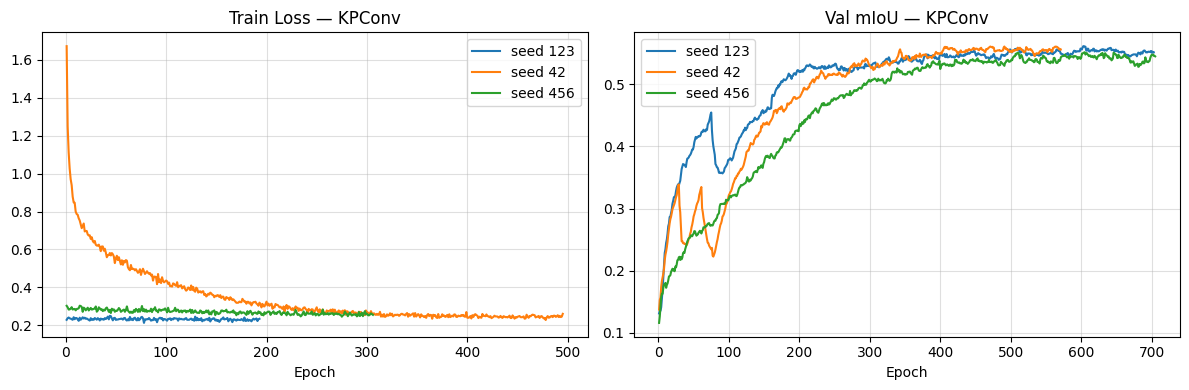

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

DRIVE_RESULTS = '/content/drive/MyDrive/Colab Notebooks/TerrainClassificationDL/results/kpconv'

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for seed_dir in sorted(os.listdir(DRIVE_RESULTS)):
    iou_file   = os.path.join(DRIVE_RESULTS, seed_dir, 'val_IoUs.txt')
    train_file = os.path.join(DRIVE_RESULTS, seed_dir, 'training.txt')
    if not os.path.exists(iou_file): continue

    with open(iou_file) as f:
        ious = [np.mean([float(x) for x in l.strip().split()]) for l in f.readlines()]
    axes[1].plot(range(1, len(ious)+1), ious, label=f'seed {seed_dir}')

    if os.path.exists(train_file):
        losses = {}
        with open(train_file) as f:
            next(f)  # skip header
            for line in f:
                parts = line.strip().split()
                if len(parts) < 3: continue
                ep = int(parts[0])
                losses.setdefault(ep, []).append(float(parts[2]))
        ep_loss = [np.mean(v) for k, v in sorted(losses.items())]
        axes[0].plot(range(1, len(ep_loss)+1), ep_loss, label=f'seed {seed_dir}')

axes[0].set_title('Train Loss — KPConv'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=.4)
axes[1].set_title('Val mIoU — KPConv'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=.4)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_RESULTS, 'convergence_all_seeds.png'), dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# import shutil

# dst = '/content/drive/MyDrive/DL_data/kpconv_results'
# shutil.copytree('/content/KPConv-PyTorch/results', dst, dirs_exist_ok=True)
# print(f"Saved to Drive: {dst}")

In [ ]:
# Install into base Colab Python (not kpconv env)
# import sys
# !{sys.executable} -m pip install -q pyntcloud pandas

# import pyntcloud
# import pandas as pd
# from IPython.display import display

# ply_path = '/content/drive/MyDrive/DL_data/kpconv_results/Log_2026-03-05_18-52-29/val_preds/08_0000020_pots.ply'

# cloud = pyntcloud.PyntCloud.from_file(ply_path)
# print(cloud.points.columns.tolist())  # see what data is in the file
# print(cloud.points.head())

In [ ]:
# import sys
# !{sys.executable} -m pip install pyntcloud

In [ ]:
# .00..0.000

In [ ]:
# Add this inside your loop after loading pts
# print(f"\nFrame: {frame}")
# print(f"GT unique classes:   {np.unique(gt)}")
# print(f"Pred unique classes: {np.unique(pre)}")
# print(f"GT unlabeled (0) points:   {np.sum(gt==0)}")
# print(f"Pred unlabeled (0) points: {np.sum(pre==0)}")

In [ ]:
# import numpy as np

# base = '/content/drive/MyDrive/DL_data/kpconv_results/Log_2026-03-05_18-52-29'

# CLASS_NAMES = [
#     'car','bicycle','motorcycle','truck','other-vehicle',
#     'person','bicyclist','motorcyclist','road','parking',
#     'sidewalk','other-ground','building','fence',
#     'vegetation','trunk','terrain','pole','traffic-sign'
# ]

# with open(f'{base}/val_IoUs.txt', 'r') as f:
#     lines = f.readlines()

# Get last epoch (current predictions)
# last_vals = [float(x) for x in lines[-1].strip().split()]

# Get best epoch 238
# best_vals = [float(x) for x in lines[238].strip().split()]

# print(f"{'Class':<20} {'Last Epoch':>12} {'Epoch 238':>12} {'Diff':>8}")
# print("-" * 55)
# for i, name in enumerate(CLASS_NAMES):
#     last = last_vals[i] * 100
#     best = best_vals[i] * 100
#     diff = last - best
#     arrow = '↑' if diff > 0 else '↓' if diff < 0 else '='
#     print(f"{name:<20} {last:>11.1f}% {best:>11.1f}% {arrow}{abs(diff):>6.1f}%")

# print("-" * 55)
# print(f"{'mIoU':<20} {np.mean(last_vals)*100:>11.1f}% {np.mean(best_vals)*100:>11.1f}%")

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.patches as mpatches
# from pyntcloud import PyntCloud
# import glob, os

# CLASS_NAMES = [
#     'car','bicycle','motorcycle','truck','other-vehicle',
#     'person','bicyclist','motorcyclist','road','parking',
#     'sidewalk','other-ground','building','fence',
#     'vegetation','trunk','terrain','pole','traffic-sign'
# ]

# base = '/content/drive/MyDrive/DL_data/kpconv_results/Log_2026-03-05_18-52-29'
# ply_files = sorted(glob.glob(f'{base}/val_preds/*_pots.ply'))

# Count GT vs Pred points per class across ALL frames
# gt_counts   = np.zeros(19)
# pred_counts = np.zeros(19)
# tp_counts   = np.zeros(19)  # correctly predicted

# print(f"Processing {len(ply_files)} frames...")
# for i, ply in enumerate(ply_files):
#     cloud = PyntCloud.from_file(ply)
#     pts   = cloud.points
#     gt    = np.clip(pts['gt'].values,  0, 18).astype(int)
#     pre   = np.clip(pts['pre'].values, 0, 18).astype(int)

#     for c in range(19):
#         gt_counts[c]   += np.sum(gt  == c)
#         pred_counts[c] += np.sum(pre == c)
#         tp_counts[c]   += np.sum((gt == c) & (pre == c))

#     if i % 10 == 0:
#         print(f"  {i}/{len(ply_files)} frames done...")

# print("Done! Plotting...")

# ── Hallucination ratio ──────────────────────────────
# ratio = pred_counts / (gt_counts + 1)  # >1 = hallucinating, <1 = missing

# ── Load val IoUs for epoch 238 ──────────────────────
# with open(f'{base}/val_IoUs.txt') as f:
#     lines = f.readlines()
# iou_vals = np.array([float(x) for x in lines[238].strip().split()])

# ── Plot ─────────────────────────────────────────────
# fig, axes = plt.subplots(3, 1, figsize=(18, 18))
# fig.patch.set_facecolor('#0d0d0d')
# for ax in axes:
#     ax.set_facecolor('#0d0d0d')

# x = np.arange(19)
# w = 0.4

# ── Plot 1: GT vs Pred point counts ──────────────────
# ax1 = axes[0]
# bars1 = ax1.bar(x - w/2, gt_counts/1e6,   width=w, color='#00c8ff', alpha=0.85, label='Ground Truth')
# bars2 = ax1.bar(x + w/2, pred_counts/1e6, width=w, color='#ff6b35', alpha=0.85, label='Prediction')
# ax1.set_xticks(x)
# ax1.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', color='white', fontsize=9)
# ax1.set_ylabel('Points (millions)', color='white')
# ax1.set_title('GT vs Predicted Point Counts per Class', color='white', fontsize=13, pad=10)
# ax1.legend(facecolor='#1a1a1a', labelcolor='white')
# ax1.tick_params(colors='white')
# ax1.spines[:].set_color('#333')
# ax1.yaxis.label.set_color('white')

# ── Plot 2: Hallucination ratio ───────────────────────
# ax2 = axes[1]
# colors = ['#ff4444' if r > 1.5 else '#ffaa00' if r > 1.1 else '#44ff88' if r > 0.9 else '#4488ff' for r in ratio]
# ax2.bar(x, ratio, color=colors, alpha=0.85)
# ax2.axhline(y=1.0, color='white', linestyle='--', linewidth=1.5, label='Perfect ratio (1.0)')
# ax2.axhline(y=1.5, color='#ff4444', linestyle=':', linewidth=1, label='Hallucination threshold (1.5x)')
# ax2.axhline(y=0.5, color='#4488ff', linestyle=':', linewidth=1, label='Missing threshold (0.5x)')
# ax2.set_xticks(x)
# ax2.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', color='white', fontsize=9)
# ax2.set_ylabel('Pred / GT ratio', color='white')
# ax2.set_title('Hallucination Ratio (>1.5x = over-predicting, <0.5x = under-predicting)', color='white', fontsize=13, pad=10)
# ax2.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
# ax2.tick_params(colors='white')
# ax2.spines[:].set_color('#333')

# Legend patches
# legend_items = [
#     mpatches.Patch(color='#ff4444', label='Hallucinating (>1.5x)'),
#     mpatches.Patch(color='#ffaa00', label='Slight over-predict (1.1–1.5x)'),
#     mpatches.Patch(color='#44ff88', label='Good balance (0.9–1.1x)'),
#     mpatches.Patch(color='#4488ff', label='Under-predicting (<0.9x)'),
# ]
# ax2.legend(handles=legend_items, facecolor='#1a1a1a', labelcolor='white', fontsize=8)

# ── Plot 3: IoU per class ─────────────────────────────
# ax3 = axes[2]
# iou_colors = ['#44ff88' if v > 0.6 else '#ffaa00' if v > 0.3 else '#ff4444' for v in iou_vals]
# ax3.bar(x, iou_vals * 100, color=iou_colors, alpha=0.85)
# ax3.axhline(y=50, color='white', linestyle='--', linewidth=1, label='50% threshold')
# ax3.set_xticks(x)
# ax3.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', color='white', fontsize=9)
# ax3.set_ylabel('IoU %', color='white')
# ax3.set_title('Per-Class IoU at Epoch 238 (green>60%, orange>30%, red<30%)', color='white', fontsize=13, pad=10)
# ax3.tick_params(colors='white')
# ax3.spines[:].set_color('#333')

# legend_items2 = [
#     mpatches.Patch(color='#44ff88', label='Strong (>60%)'),
#     mpatches.Patch(color='#ffaa00', label='Moderate (30–60%)'),
#     mpatches.Patch(color='#ff4444', label='Weak (<30%)'),
# ]
# ax3.legend(handles=legend_items2, facecolor='#1a1a1a', labelcolor='white', fontsize=8)

# plt.suptitle('KPConv SemanticKITTI — Full Analysis Dashboard',
#              color='white', fontsize=16, fontweight='bold', y=1.01)
# plt.tight_layout()

# save_path = '/content/drive/MyDrive/DL_data/kpconv_analysis_dashboard.png'
# plt.savefig(save_path, dpi=150, facecolor='#0d0d0d', bbox_inches='tight')
# plt.show()
# print(f"\n✅ Saved to: {save_path}")

# ── Print summary table ───────────────────────────────
# print(f"\n{'Class':<20} {'GT pts':>10} {'Pred pts':>10} {'Ratio':>8} {'IoU':>8} {'Issue'}")
# print("-" * 70)
# for i, name in enumerate(CLASS_NAMES):
#     r = ratio[i]
#     issue = '🔴 HALLUCINATING' if r > 1.5 else '🟡 slight over' if r > 1.1 else '✅ good' if r > 0.9 else '🔵 under-pred'
#     print(f"{name:<20} {int(gt_counts[i]):>10,} {int(pred_counts[i]):>10,} {r:>7.2f}x {iou_vals[i]*100:>7.1f}% {issue}")

In [ ]:
# import pyntcloud, numpy as np, matplotlib.pyplot as plt, matplotlib.patches as mpatches
# from mpl_toolkits.mplot3d import Axes3D

# CLASS_NAMES = [
#     'car','bicycle','motorcycle','truck','other-vehicle',
#     'person','bicyclist','motorcyclist','road','parking',
#     'sidewalk','other-ground','building','fence',
#     'vegetation','trunk','terrain','pole','traffic-sign'
# ]
# CLASS_COLOURS = np.array([
#     [100,150,245],[100,230,245],[30,60,150],[80,30,180],[100,80,250],
#     [155,30,30],[255,40,200],[255,0,255],[75,0,75],[75,0,175],
#     [0,200,255],[50,120,255],[0,175,0],[0,60,135],[80,240,150],
#     [150,240,255],[0,50,255],[170,30,250],[255,0,50]
# ], dtype=np.float32) / 255.0

# ply_files = [
#     '/content/drive/MyDrive/DL_data/kpconv_results/Log_2026-03-05_18-52-29/val_preds/08_0000400_pots.ply',
#     '/content/drive/MyDrive/DL_data/kpconv_results/Log_2026-03-05_18-52-29/val_preds/08_0000420_pots.ply',
#     '/content/drive/MyDrive/DL_data/kpconv_results/Log_2026-03-05_18-52-29/val_preds/08_0000700_pots.ply',
# ]

# for ply_path in ply_files:
#     frame = ply_path.split('/')[-1].replace('_pots.ply', '')
#     print(f"Rendering {frame}...")

#     cloud = pyntcloud.PyntCloud.from_file(ply_path)
#     pts   = cloud.points

#     x   = pts['x'].values
#     y   = pts['y'].values
#     z   = pts['z'].values
#     pre = np.clip(pts['pre'].values, 0, 18)
#     colours = CLASS_COLOURS[pre]

#     fig = plt.figure(figsize=(22, 18))
#     fig.patch.set_facecolor('black')

#     views = [
#         (221, "Bird's Eye (X-Y)", x, y, 'X →', 'Y →'),
#         (222, 'Front View (X-Z)', x, z, 'X →', 'Z (height) →'),
#         (223, 'Side View (Y-Z)',  y, z, 'Y →', 'Z (height) →'),
#     ]

#     for pos, title, a, b, xl, yl in views:
#         ax = fig.add_subplot(pos)
#         ax.set_facecolor('black')
#         ax.scatter(a[::4], b[::4], c=colours[::4], s=0.8, linewidths=0)
#         ax.set_title(title, color='white', fontsize=12)
#         ax.set_xlabel(xl, color='white', fontsize=9)
#         ax.set_ylabel(yl, color='white', fontsize=9)
#         ax.tick_params(colors='white')

    # Fixed 3D view
#     ax3d = fig.add_subplot(224, projection='3d')
#     ax3d.set_facecolor('black')
#     ax3d.view_init(elev=25, azim=-60)
#     ax3d.set_xlim(-40, 40)
#     ax3d.set_ylim(-40, 40)
#     ax3d.set_zlim(-3, 3)
#     mask = (np.abs(x) < 40) & (np.abs(y) < 40) & (np.abs(z) < 3)
#     ax3d.scatter(x[mask][::4], y[mask][::4], z[mask][::4],
#                  c=colours[mask][::4], s=0.8, linewidths=0)
#     ax3d.set_title('3D View', color='white', fontsize=12)
#     ax3d.set_xlabel('X', color='white', fontsize=8)
#     ax3d.set_ylabel('Y', color='white', fontsize=8)
#     ax3d.set_zlabel('Z', color='white', fontsize=8)
#     ax3d.tick_params(colors='white')
#     ax3d.xaxis.pane.fill = False
#     ax3d.yaxis.pane.fill = False
#     ax3d.zaxis.pane.fill = False
#     ax3d.xaxis.pane.set_edgecolor('gray')
#     ax3d.yaxis.pane.set_edgecolor('gray')
#     ax3d.zaxis.pane.set_edgecolor('gray')

    # Legend
#     unique  = np.unique(pre)
#     patches = [mpatches.Patch(color=CLASS_COLOURS[c], label=CLASS_NAMES[c])
#                for c in unique if c < 19]
#     fig.legend(handles=patches, loc='lower center', ncol=10, fontsize=8,
#                facecolor='black', labelcolor='white', framealpha=0.5)

#     plt.suptitle(f'KPConv Predicted Labels — Seq 08 Frame {frame}',
#                  color='white', fontsize=15, y=1.01)
#     plt.tight_layout()

#     save_path = f'/content/drive/MyDrive/DL_data/pointcloud_{frame}.png'
#     plt.savefig(save_path, dpi=150, facecolor='black', bbox_inches='tight')
#     plt.show()
#     plt.close()
#     print(f"  Saved: {save_path}")

# print("All frames done!")

In [ ]:
# List saved checkpoints on Drive
# import os
# ckpt_dir = '/content/drive/MyDrive/DL_data/kpconv_checkpoints'
# if os.path.exists(ckpt_dir):
#     for f in sorted(os.listdir(ckpt_dir)):
#         print(f)
# else:
#     print('No checkpoints directory yet — training may not have started.')

In [ ]:
# ── Resume seed 123
# !/usr/local/envs/kpconv/bin/python /content/run_kpconv.py 123 "/content/drive/MyDrive/Colab Notebooks/TerrainClassificationDL" "/content/drive/MyDrive/Colab Notebooks/TerrainClassificationDL/results/kpconv"

Streaming output truncated to the last 5000 lines.
e561-i0438 => L=0.242 acc= 90% / t(ms):   6.0  48.0  72.9)
e561-i0446 => L=0.102 acc= 98% / t(ms):   5.9  48.2  77.5)
e561-i0454 => L=0.284 acc= 90% / t(ms):   5.4  46.5  79.3)
e561-i0463 => L=0.590 acc= 81% / t(ms):   7.1  45.7  73.6)
e561-i0472 => L=0.395 acc= 79% / t(ms):   6.8  40.6  75.6)
e561-i0481 => L=0.190 acc= 96% / t(ms):   5.9  41.6  74.7)
e561-i0490 => L=0.224 acc= 89% / t(ms):   5.7  36.3  74.6)
Validation : 0.0% (timings : 91.84 24.40)
Validation : 3.5% (timings : 64.33 63.83)
Validation : 8.0% (timings : 40.75 82.73)
Validation : 12.5% (timings : 25.87 96.95)
Validation : 16.0% (timings : 18.19 270.01)
Validation : 20.5% (timings : 11.63 213.32)
Validation : 25.5% (timings : 7.11 173.56)
Validation : 30.0% (timings : 4.72 151.68)
Validation : 34.5% (timings : 3.19 139.40)
Validation : 39.0% (timings : 2.15 130.22)
Validation : 43.0% (timings : 1.55 131.76)
Validation : 47.5% (timings : 1.12 126.25)
Validation : 51.5% (t

In [ ]:
with open('/content/run_kpconv.py', 'r') as f:
    content = f.read()

early_stopping = '''
class EarlyStoppingTrainer(ModelTrainer):
    def __init__(self, net, config, seed, drive_results, patience=100, chkp_path=None):
        super().__init__(net, config, chkp_path=chkp_path)
        self.patience          = patience
        self.best_miou         = 0.0
        self.epochs_no_improve = 0
        self.seed              = seed
        self.drive_seed_dir    = os.path.join(drive_results, str(seed))
        os.makedirs(self.drive_seed_dir, exist_ok=True)

    def validation(self, net, val_loader, config):
        super().validation(net, val_loader, config)
        drive_iou = os.path.join(config.saving_path, 'val_IoUs.txt')
        if os.path.exists(drive_iou):
            with open(drive_iou) as f:
                lines = f.readlines()
            if lines:
                vals = [float(x) for x in lines[-1].strip().split()]
                miou = float(np.mean(vals))
                if miou > self.best_miou + 1e-4:
                    self.best_miou         = miou
                    self.epochs_no_improve = 0
                else:
                    self.epochs_no_improve += 1
                print(f'  [Early stopping] mIoU={miou:.4f} best={self.best_miou:.4f} no_improve={self.epochs_no_improve}/{self.patience}')
                if self.epochs_no_improve >= self.patience:
                    print(f'  [Early stopping] Triggered at epoch {self.epoch}')
                    pid_file = os.path.join(config.saving_path, 'running_PID.txt')
                    if os.path.exists(pid_file):
                        os.remove(pid_file)

'''

content = content.replace('return f, w\n\n', 'return f, w\n' + early_stopping)

with open('/content/run_kpconv.py', 'w') as f:
    f.write(content)

!python3 -c "import ast; ast.parse(open('/content/run_kpconv.py').read()); print('Syntax OK')"

Syntax OK
